
# Lab: Unsupervised Well-Performance Segmentation with K-Means Clustering
### From Supervised Models (Regression / Classification) to Unsupervised Pattern Discovery

**Domain:** Upstream Production Optimization — Oil Well Performance Segmentation
**Business question:** *Without any labels telling us which wells are "good" or "bad," can we automatically discover natural performance groups in our well portfolio — and turn those groups into a targeted field action plan?*

---

## Lab Objectives
By the end of this lab, you will be able to:
1. Explain how **unsupervised learning** differs from the regression and classification labs — no target column exists; the algorithm finds structure in the features alone.
2. Prepare data correctly for a **distance-based** algorithm (why feature scaling is mandatory for K-Means, unlike for tree-based models).
3. Use the **Elbow Method** and **Silhouette Analysis** to choose the number of clusters, *K*, in a defensible, data-driven way.
4. Fit and interpret a **K-Means** clustering model.
5. **Profile** each cluster using its centroid and translate that profile into a plain-English business label.
6. Visualize high-dimensional clusters in 2D using **PCA**.
7. Validate the discovered clusters against known well categories (a luxury we have in this teaching dataset but not in most real unsupervised problems).
8. Package the workflow into a reusable function that assigns **new wells** to a segment and a recommended action — the unsupervised-learning equivalent of the alert workflow built in the classification lab.

## Why This Matters (SME Note)
Classification (previous lab) answers *"will this specific thing happen?"* when you already have historical examples labeled Yes/No. But very often in Oil & Gas, **you don't have labels at all** — nobody has gone through your 1,000+ wells and manually tagged each one as "Star Performer" or "Decline Candidate." **K-Means clustering** is the workhorse technique for this situation: it looks only at the *feature* similarities between wells and groups them automatically. This is one of the most common real-world applications of unsupervised learning in upstream analytics: **well/reservoir segmentation, rig/crew performance grouping, facility anomaly grouping, and customer/asset portfolio triage** all start from exactly this pattern.



## Step 0 — Environment Setup

- `pandas` / `numpy` — data handling
- `matplotlib` / `seaborn` — visualization
- `scikit-learn` — `StandardScaler`, `KMeans`, `PCA`, `silhouette_score`
- `joblib` — persist the fitted scaler + model for reuse


In [1]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples, adjusted_rand_score
import joblib

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 4.5)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries loaded successfully.")


Libraries loaded successfully.



## Step 1 — The Business Dataset: Well Performance & Operating Characteristics

We simulate a portfolio of **1,200 producing oil wells**, each described by operational KPIs you would pull from a production allocation system / SCADA historian, plus static reservoir descriptors from the well file. Unlike the classification lab, **there is no target column** — that is the entire point of unsupervised learning: the model must find structure using the features alone.

| Feature | Description | Role |
|---|---|---|
| `avg_oil_rate_bopd` | Average oil rate, barrels of oil per day | Clustering feature |
| `water_cut_pct` | % water in produced fluid | Clustering feature |
| `gas_oil_ratio_scf_bbl` | Gas-oil ratio | Clustering feature |
| `decline_rate_pct_per_month` | Production decline rate | Clustering feature |
| `reservoir_pressure_psi` | Current reservoir pressure | Clustering feature |
| `choke_size_64th` | Surface choke setting | Clustering feature |
| `well_depth_ft` | True vertical depth | Supplementary — used only to *profile* clusters afterward |
| `porosity_pct` | Reservoir rock porosity | Supplementary — profiling only |
| `permeability_md` | Reservoir rock permeability | Supplementary — profiling only |

> **Instructor note:** we deliberately cluster on **operational/performance KPIs** (the first 6 rows) rather than static reservoir rock properties. This mirrors real practice: you typically segment wells by *how they are behaving*, then use static reservoir descriptors afterward to help **explain** *why* a cluster behaves the way it does. For this teaching dataset only, we also generate a hidden `_true_type` label (5 realistic well archetypes) purely so we can sanity-check the clustering result in Step 9 — in a real project this label would not exist.


In [2]:

n = 1200

archetypes = ['Star Performer', 'Steady Producer', 'Watered-Out', 'High-GOR/Gas-Heavy', 'Marginal/Decline']
weights = [0.12, 0.33, 0.22, 0.13, 0.20]
true_type = np.random.choice(archetypes, size=n, p=weights)

def draw(mean, sd, lo=None, hi=None):
    x = np.random.normal(mean, sd)
    if lo is not None: x = max(x, lo)
    if hi is not None: x = min(x, hi)
    return x

rows = []
for t in true_type:
    if t == 'Star Performer':
        row = [draw(850, 120), draw(8, 4, 0, 100), draw(600, 80), draw(2.5, 1.0, 0), draw(3800, 300), draw(28, 4)]
    elif t == 'Steady Producer':
        row = [draw(400, 70), draw(25, 8, 0, 100), draw(550, 90), draw(5.0, 1.5, 0), draw(3100, 350), draw(20, 4)]
    elif t == 'Watered-Out':
        row = [draw(180, 60), draw(78, 10, 0, 100), draw(480, 100), draw(7.0, 2.0, 0), draw(2400, 400), draw(16, 4)]
    elif t == 'High-GOR/Gas-Heavy':
        row = [draw(300, 90), draw(15, 6, 0, 100), draw(1400, 250), draw(6.0, 2.0, 0), draw(2900, 400), draw(22, 5)]
    else:  # Marginal/Decline
        row = [draw(90, 40), draw(55, 15, 0, 100), draw(520, 120), draw(11.0, 3.0, 0), draw(1900, 350), draw(12, 4)]
    rows.append(row)

df = pd.DataFrame(rows, columns=[
    'avg_oil_rate_bopd', 'water_cut_pct', 'gas_oil_ratio_scf_bbl',
    'decline_rate_pct_per_month', 'reservoir_pressure_psi', 'choke_size_64th'
])

df['well_depth_ft'] = np.random.normal(9500, 1600, n).clip(3000, None)
df['porosity_pct'] = np.random.normal(14, 3, n).clip(4, 30)
df['permeability_md'] = np.random.gamma(2.2, 40, n)
df['well_id'] = [f"WELL-{i:04d}" for i in range(n)]
df['_true_type'] = true_type   # hidden — for validation only, NOT used in clustering

print("Dataset shape:", df.shape)
df.drop(columns=['_true_type']).head()


Dataset shape: (1200, 11)


,avg_oil_rate_bopd,water_cut_pct,gas_oil_ratio_scf_bbl,decline_rate_pct_per_month,reservoir_pressure_psi,choke_size_64th,well_depth_ft,porosity_pct,permeability_md,well_id
0,509.586682,24.473998,500.032043,7.821736,2593.195135,11.204776,9208.543066,14.675809,155.058379,WELL-0000
1,107.600578,47.469187,397.452062,13.125069,1985.330250,9.743685,9949.938692,15.820286,76.362975,WELL-0001
2,184.772604,20.234744,1562.550294,5.801648,3638.654798,16.649576,9063.189203,18.232077,53.336452,WELL-0002
3,88.468490,71.080919,475.441398,7.486679,2303.505577,17.408222,10436.034132,13.070868,128.696756,WELL-0003
4,312.392240,36.550117,542.606394,6.675944,3219.953871,21.827013,9949.907229,12.276540,152.137678,WELL-0004



### Explanation of the logic
- Each of the 5 hidden archetypes (`_true_type`) is given a distinct combination of production-KPI distributions — e.g. a **Star Performer** has high oil rate, low water cut, and a slow decline rate, while a **Watered-Out** well has low oil rate and high water cut. This is only a simulation device so the class works from a realistic, reproducible dataset; the clustering algorithm in Step 4 will never see this column.
- `well_depth_ft`, `porosity_pct`, and `permeability_md` are generated **independently of well archetype** — deliberately, so they act as neutral, descriptive context rather than leaking the answer into the clustering.


In [3]:

df.to_csv("well_segmentation_data.csv", index=False)
df.drop(columns=['well_id', '_true_type']).describe().T.round(1)


,count,mean,std,min,25%,50%,75%,max
avg_oil_rate_bopd,1200.0,331.0,249.1,-18.2,134.7,287.6,427.5,1203.2
water_cut_pct,1200.0,39.7,27.2,0.0,16.9,30.4,64.8,100.0
gas_oil_ratio_scf_bbl,1200.0,634.2,306.6,165.5,473.9,555.2,643.8,1913.5
decline_rate_pct_per_month,1200.0,6.5,3.4,0.0,4.1,6.1,8.3,19.6
reservoir_pressure_psi,1200.0,2770.6,706.7,843.2,2211.5,2805.2,3291.0,4545.6
choke_size_64th,1200.0,18.5,6.5,0.6,13.9,18.3,22.9,39.7
well_depth_ft,1200.0,9535.4,1600.1,3361.4,8484.1,9531.6,10583.5,14903.8
porosity_pct,1200.0,14.0,2.9,4.0,12.0,14.0,15.9,22.7
permeability_md,1200.0,87.5,56.1,1.5,46.8,74.3,116.1,356.2



## Step 2 — Exploratory Data Analysis (EDA)

Even without a target variable, EDA is essential before clustering: we need to understand each feature's distribution and scale, and check for obvious multi-modal patterns that hint at natural groupings.


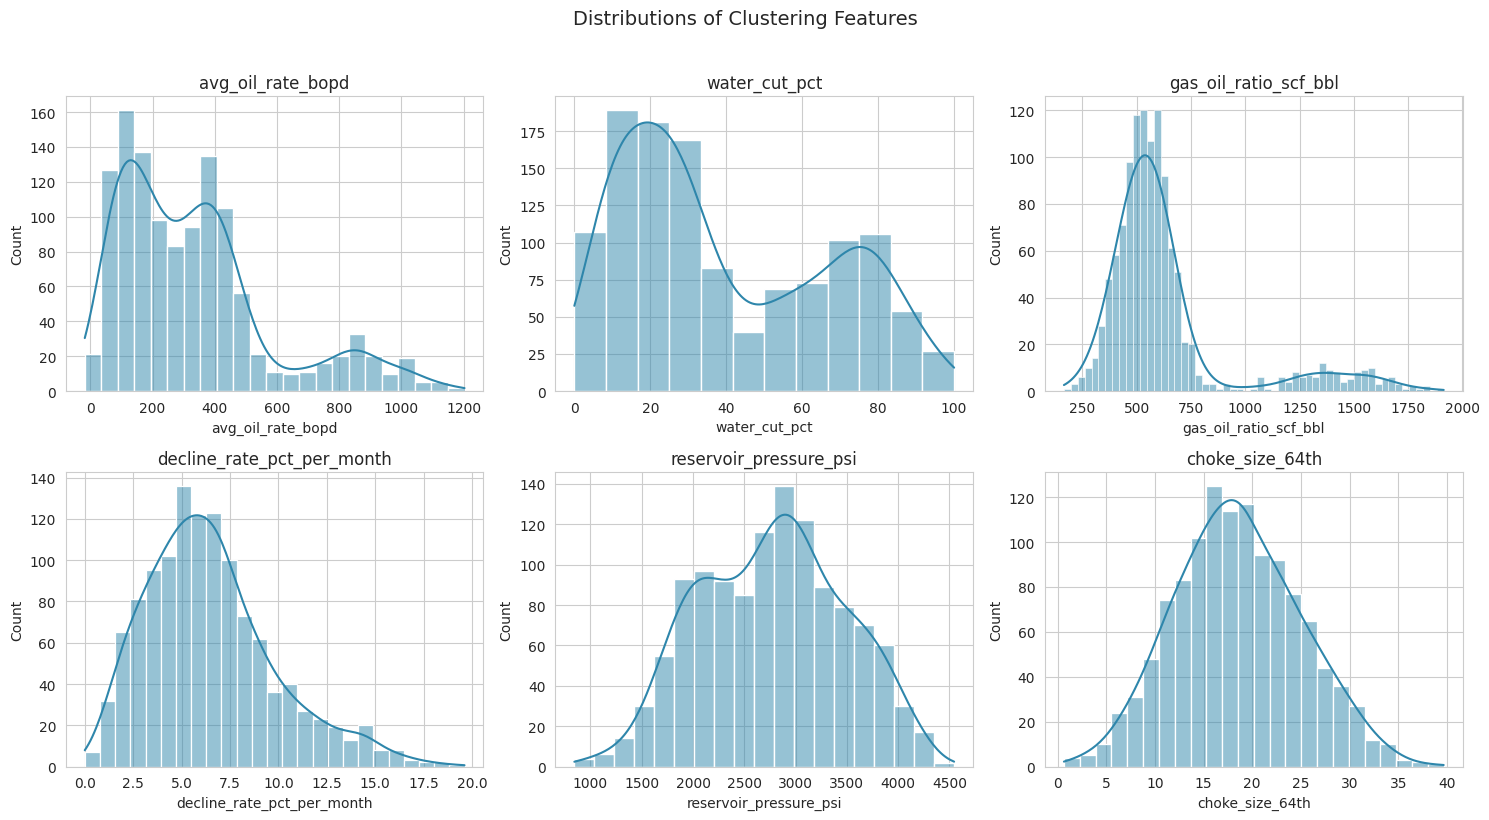

In [4]:

feat_cols = ['avg_oil_rate_bopd', 'water_cut_pct', 'gas_oil_ratio_scf_bbl',
             'decline_rate_pct_per_month', 'reservoir_pressure_psi', 'choke_size_64th']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), feat_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='#2E86AB')
    ax.set_title(col)
plt.suptitle("Distributions of Clustering Features", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


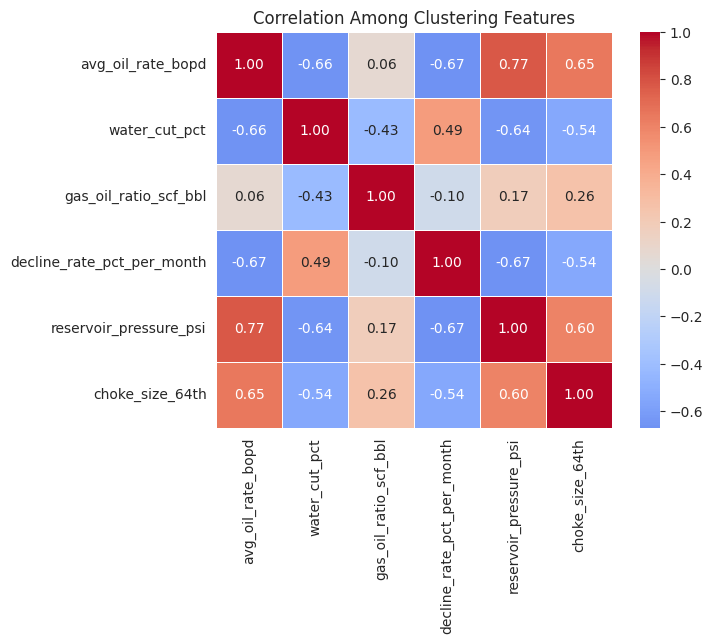

In [5]:

plt.figure(figsize=(8, 6.5))
corr = df[feat_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0, square=True, linewidths=0.4)
plt.title("Correlation Among Clustering Features")
plt.tight_layout()
plt.show()



### Explanation of the logic
- The histograms already hint that several features (e.g. `avg_oil_rate_bopd`, `water_cut_pct`) are **multi-modal or skewed** rather than perfectly bell-shaped — a visual clue that the portfolio may contain sub-populations, which is exactly what we hope K-Means will separate.
- The correlation heatmap checks for near-duplicate features. Two strongly correlated features would otherwise implicitly get **double weight** in the distance calculation K-Means uses internally — worth knowing about even though we keep all features here because each carries a distinct engineering meaning.



## Step 3 — Feature Scaling (Mandatory for K-Means)

**This is the single most important data-preparation step in this lab.** K-Means groups points by **Euclidean distance**. If features are left on their raw scales, a feature like `reservoir_pressure_psi` (values in the thousands) would completely dominate the distance calculation over a feature like `water_cut_pct` (values 0–100) — not because pressure is more important, but purely because of its numeric scale.

We use `StandardScaler`, which transforms every feature to **mean 0, standard deviation 1**:

$$ z = \frac{x - \mu}{\sigma} $$


In [6]:

X = df[feat_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=feat_cols)

print("Before scaling (raw units):")
print(X.describe().loc[['mean', 'std']].round(1))
print("\nAfter scaling (mean ~0, std ~1):")
print(X_scaled_df.describe().loc[['mean', 'std']].round(2))


Before scaling (raw units):
      avg_oil_rate_bopd  water_cut_pct  gas_oil_ratio_scf_bbl  \
mean              331.0           39.7                  634.2   
std               249.1           27.2                  306.6   

      decline_rate_pct_per_month  reservoir_pressure_psi  choke_size_64th  
mean                         6.5                  2770.6             18.5  
std                          3.4                   706.7              6.5  

After scaling (mean ~0, std ~1):
      avg_oil_rate_bopd  water_cut_pct  gas_oil_ratio_scf_bbl  \
mean                0.0           -0.0                   -0.0   
std                 1.0            1.0                    1.0   

      decline_rate_pct_per_month  reservoir_pressure_psi  choke_size_64th  
mean                         0.0                     0.0             -0.0  
std                          1.0                     1.0              1.0  



### Explanation of the logic
Compare the two tables: every raw feature had a wildly different mean and spread (pressure in the thousands, water cut in tens), while after scaling every feature has mean ≈ 0 and standard deviation ≈ 1. Now each of the six features contributes **comparably** to the distance calculation, and the clusters K-Means finds will reflect genuine multi-dimensional similarity rather than an accident of measurement units.

> **Contrast with the classification lab:** Random Forest and XGBoost split on one feature threshold at a time, so their splits are unaffected by scale. K-Means (and any distance-based method, including PCA and k-NN) is **directly** affected by scale — always scale first.



## Step 4 — Choosing the Number of Clusters (K): Elbow Method & Silhouette Analysis

K-Means requires us to specify *K* up front. We evaluate a range of candidate values using two complementary, standard techniques:

1. **Elbow Method** — plots *inertia* (the sum of squared distances of each point to its assigned cluster centroid) against *K*. Inertia always decreases as *K* increases (more clusters can only fit the data at least as well), so we look for the "elbow" — the point where adding another cluster stops producing a meaningful improvement.
2. **Silhouette Score** — for each point, measures how much closer it is to its own cluster than to the next-nearest cluster, on a scale of −1 (likely mis-clustered) to +1 (well clustered). We average this across all points for each candidate *K*; **higher is better**.


In [7]:

k_range = range(2, 10)
inertias = []
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

results_k = pd.DataFrame({'k': list(k_range), 'inertia': inertias, 'silhouette': silhouette_scores}).round(3)
results_k


,k,inertia,silhouette
0,2,3919.196,0.403
1,3,2918.973,0.430
2,4,2136.935,0.421
3,5,1697.320,0.395
4,6,1567.157,0.369
5,7,1460.906,0.285
6,8,1397.005,0.262
7,9,1344.466,0.260


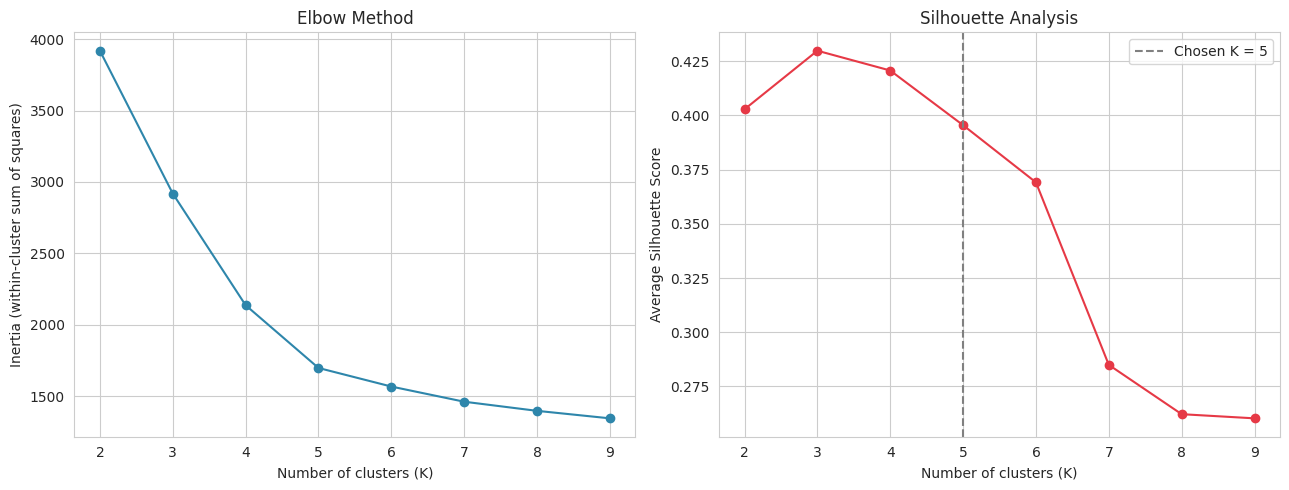

Silhouette-optimal K: 3


In [8]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(list(k_range), inertias, marker='o', color='#2E86AB')
axes[0].set_xlabel("Number of clusters (K)")
axes[0].set_ylabel("Inertia (within-cluster sum of squares)")
axes[0].set_title("Elbow Method")

axes[1].plot(list(k_range), silhouette_scores, marker='o', color='#E63946')
axes[1].set_xlabel("Number of clusters (K)")
axes[1].set_ylabel("Average Silhouette Score")
axes[1].set_title("Silhouette Analysis")
axes[1].axvline(5, color='gray', linestyle='--', label="Chosen K = 5")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Silhouette-optimal K:", results_k.loc[results_k['silhouette'].idxmax(), 'k'])



### Explanation of the logic
- The **elbow curve** bends noticeably around K = 4–5 and flattens afterward — beyond that point, adding clusters buys only a small further reduction in inertia at the cost of a much harder-to-interpret model.
- The **silhouette curve** is actually highest at K = 3, decreasing only modestly through K = 4 and K = 5 before dropping off more sharply at K ≥ 6. Statistically, K = 3 looks attractive — but a quick check of what K = 3 actually merges together tells a more important story:


In [9]:

# Diagnostic: what does the "statistically best" K=3 actually merge together?
km3_check = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE).fit(X_scaled)
print(pd.crosstab(km3_check.labels_, df['_true_type']))


_true_type  High-GOR/Gas-Heavy  Marginal/Decline  Star Performer  \
row_0                                                              
0                            7                 0             159   
1                            0               253               0   
2                          136                 0               0   

_true_type  Steady Producer  Watered-Out  
row_0                                     
0                       375            1  
1                         5          264  
2                         0            0  



At **K = 3**, two pairs of operationally very different well types get merged into single clusters: **Star Performers get folded in with ordinary Steady Producers**, and **Marginal/Decline wells get folded in with Watered-Out wells**. A production engineer using this K = 3 segmentation would lose exactly the distinctions that matter most for prioritizing capital — it can no longer tell you which wells are truly worth protecting versus merely adequate, or which underperformers need a water-shutoff treatment versus a full economic review.

**We choose K = 5 instead**, because: (a) its silhouette score (0.395) is only modestly below the K = 3 maximum (0.430) — a small, acceptable trade-off — and (b) five clusters recover five operationally distinct, independently actionable well categories that map directly onto different field interventions (see Step 6 and Step 10).



> **Instructor discussion point:** this is a genuinely important, recurring judgment call in applied clustering. The "statistically optimal" K by silhouette score is not automatically the "best" K for the business. When a slightly lower-scoring K produces a segmentation that is *meaningfully more actionable and interpretable*, prefer it. A clustering that nobody can explain or act on has limited business value, however good its silhouette score.



## Step 5 — Fitting the K-Means Model (K = 5)


In [10]:

K_CHOSEN = 5
kmeans = KMeans(n_clusters=K_CHOSEN, n_init=10, random_state=RANDOM_STATE)
df['cluster'] = kmeans.fit_predict(X_scaled)

print(f"K-Means fit with K={K_CHOSEN}.")
print("\nWells per cluster:")
print(df['cluster'].value_counts().sort_index())

overall_silhouette = silhouette_score(X_scaled, df['cluster'])
print(f"\nOverall silhouette score at K={K_CHOSEN}: {overall_silhouette:.3f}")


K-Means fit with K=5.

Wells per cluster:
cluster
0    160
1    209
2    136
3    388
4    307
Name: count, dtype: int64

Overall silhouette score at K=5: 0.395



### Explanation of the logic
- `n_init=10` tells K-Means to run the entire algorithm **10 times from different random starting centroids** and keep the best result (lowest inertia). K-Means is sensitive to its random initialization and can converge to a poor local optimum from a single run — `n_init=10` is a standard, cheap safeguard.
- `fit_predict()` does two things in one call: it fits the cluster centroids to the scaled data, and returns the cluster label (0–4) assigned to every well.
- An overall silhouette score in the 0.3–0.5 range (as we see here) indicates **reasonable, usable cluster structure** — real business data is rarely as cleanly separated as a textbook example, and this is a realistic, healthy result.



## Step 6 — Cluster Profiling: What Does Each Cluster Actually Mean?

A cluster is just a number (0, 1, 2, 3, 4) until we look at what makes it different. We profile each cluster by its **centroid** — the average value of each feature within that cluster, back-transformed to real-world units.


In [11]:

cluster_profile = df.groupby('cluster')[feat_cols + ['well_depth_ft', 'porosity_pct', 'permeability_md']].mean().round(1)
cluster_profile['n_wells'] = df['cluster'].value_counts().sort_index()
cluster_profile


,avg_oil_rate_bopd,water_cut_pct,gas_oil_ratio_scf_bbl,decline_rate_pct_per_month,reservoir_pressure_psi,choke_size_64th,well_depth_ft,porosity_pct,permeability_md,n_wells
cluster,,,,,,,,,,
0,851.4,8.4,617.1,2.4,3816.2,27.6,9550.9,13.7,92.0,160
1,91.2,54.7,517.0,11.8,1896.6,11.5,9600.0,13.7,82.6,209
2,289.8,15.1,1416.9,6.2,2942.3,21.8,9585.0,14.1,83.0,136
3,395.5,25.3,554.7,5.0,3094.8,19.7,9573.5,14.2,87.4,388
4,159.7,75.0,476.8,7.0,2335.0,15.7,9413.1,14.0,90.4,307


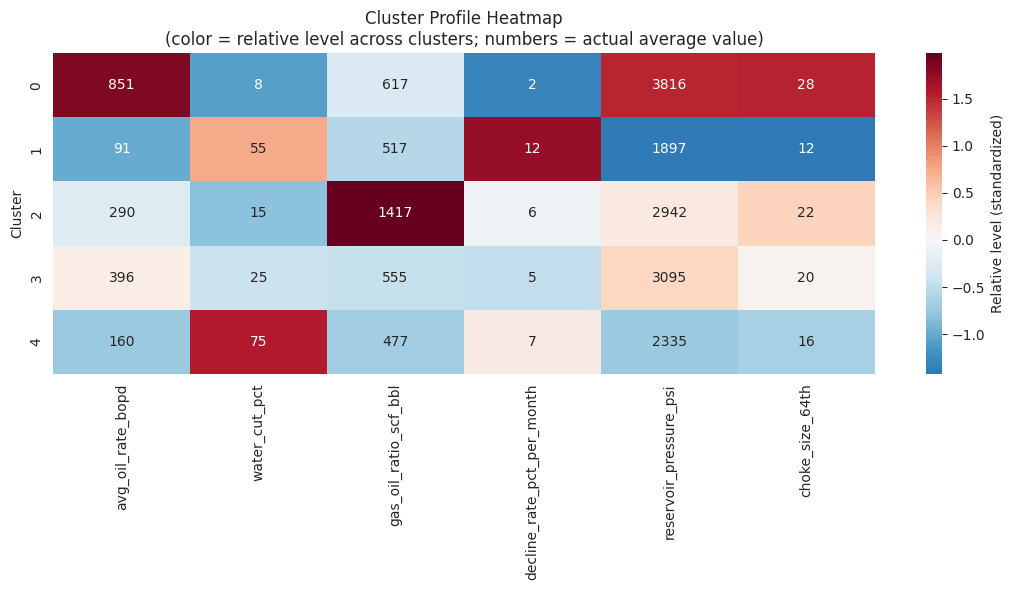

In [12]:

fig, ax = plt.subplots(figsize=(11, 6))
profile_z = pd.DataFrame(
    StandardScaler().fit_transform(cluster_profile[feat_cols]),
    columns=feat_cols, index=cluster_profile.index
)
sns.heatmap(profile_z, annot=cluster_profile[feat_cols].values, fmt=".0f", cmap='RdBu_r', center=0,
            cbar_kws={'label': 'Relative level (standardized)'}, ax=ax)
ax.set_title("Cluster Profile Heatmap\n(color = relative level across clusters; numbers = actual average value)")
ax.set_ylabel("Cluster")
plt.tight_layout()
plt.show()



### Explanation of the logic
- Grouping by `cluster` and averaging each feature gives the **centroid profile** in real, interpretable units (barrels/day, %, psi, etc.) rather than the standardized values the algorithm actually used internally — this is what makes the result usable in a business conversation.
- The heatmap encodes each cell's **color** by its standardized (relative) level across clusters, while the **printed number** is the real-world average — this lets us see at a glance which clusters run "hot" (red) or "cold" (blue) on each metric, while still reading exact values.
- Based on this profile, we can now assign each numeric cluster a **plain-English business label**:


In [13]:

# Business labeling — derived by inspecting the cluster_profile table above.
# NOTE: cluster-to-label mapping must be re-verified any time the model is refit,
# since KMeans cluster numbers (0-4) are arbitrary and can shuffle between runs.
cluster_labels = {
    cluster_profile['avg_oil_rate_bopd'].idxmax(): 'Star Performer',
    cluster_profile['water_cut_pct'].idxmax(): 'Watered-Out',
    cluster_profile['gas_oil_ratio_scf_bbl'].idxmax(): 'High-GOR / Gas-Heavy',
    cluster_profile['decline_rate_pct_per_month'].idxmax(): 'Marginal / Decline Candidate',
}
# whichever cluster hasn't been claimed yet is the "Steady Producer" middle-of-the-pack group
remaining = [c for c in cluster_profile.index if c not in cluster_labels]
for c in remaining:
    cluster_labels[c] = 'Steady Producer'

df['segment'] = df['cluster'].map(cluster_labels)
print(cluster_labels)
print("\nWells per segment:")
print(df['segment'].value_counts())


{np.int32(0): 'Star Performer', np.int32(4): 'Watered-Out', np.int32(2): 'High-GOR / Gas-Heavy', np.int32(1): 'Marginal / Decline Candidate', 3: 'Steady Producer'}

Wells per segment:
segment
Steady Producer                 388
Watered-Out                     307
Marginal / Decline Candidate    209
Star Performer                  160
High-GOR / Gas-Heavy            136
Name: count, dtype: int64



### Explanation of the logic
Rather than hand-picking labels by eye, this cell derives them **programmatically** from the profile table: whichever cluster has the highest average oil rate is called `Star Performer`, whichever has the highest water cut is `Watered-Out`, and so on, with the leftover cluster defaulting to `Steady Producer`. This is a reproducible convention that survives a re-run of the notebook (cluster *numbers* 0–4 are arbitrary and can shuffle between runs, but the *labeling rule* always re-attaches the right name to the right centroid).



## Step 7 — Visualizing Clusters in 2D with PCA

We clustered in 6-dimensional feature space, which cannot be plotted directly. **Principal Component Analysis (PCA)** compresses the 6 scaled features into the 2 directions (components) that capture the most variance, purely for visualization.


Variance explained by PC1 and PC2: [0.597 0.178]   (total: 0.775 )


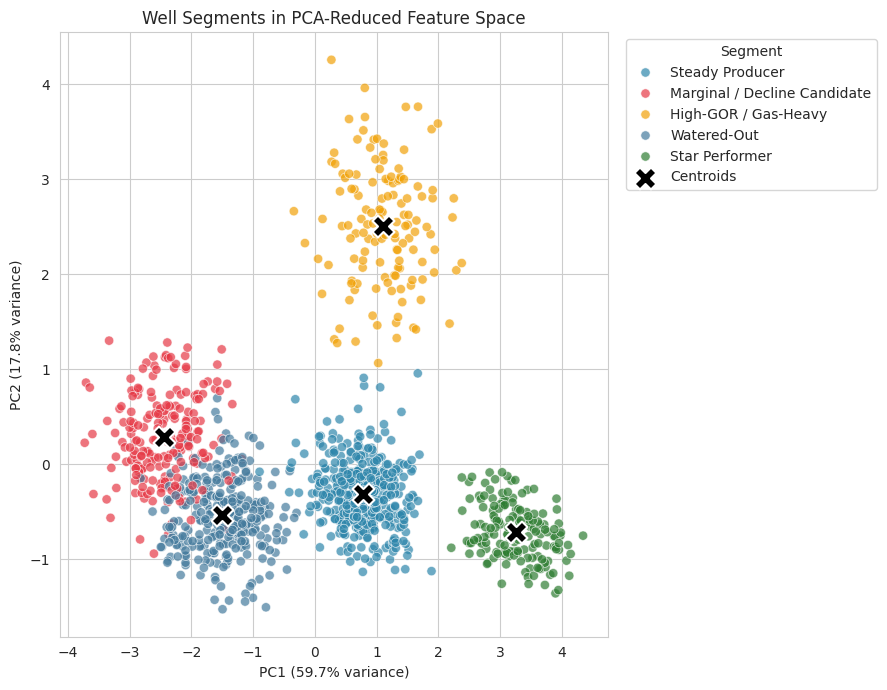

In [14]:

pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_coords = pca.fit_transform(X_scaled)
df['pca1'] = pca_coords[:, 0]
df['pca2'] = pca_coords[:, 1]

print("Variance explained by PC1 and PC2:", np.round(pca.explained_variance_ratio_, 3),
      "  (total:", round(pca.explained_variance_ratio_.sum(), 3), ")")

fig, ax = plt.subplots(figsize=(9, 7))
palette = {'Star Performer': '#2E7D32', 'Steady Producer': '#2E86AB', 'Watered-Out': '#457B9D',
           'High-GOR / Gas-Heavy': '#F1A208', 'Marginal / Decline Candidate': '#E63946'}
sns.scatterplot(data=df, x='pca1', y='pca2', hue='segment', palette=palette, alpha=0.7, s=45, ax=ax)

centroids_pca = pca.transform(kmeans.cluster_centers_)
ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='black', marker='X', s=250,
           edgecolor='white', linewidth=1.5, label='Centroids', zorder=5)

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
ax.set_title("Well Segments in PCA-Reduced Feature Space")
ax.legend(title="Segment", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()



### Explanation of the logic
- PCA is used **only for visualization** here — the clustering itself was performed on the full 6-dimensional scaled feature space in Step 5, not on these 2 components. Reducing to 2D lets us *see* what K-Means found, but the actual model uses the richer representation.
- The black **X** markers are the actual cluster centroids (transformed into the same PCA space), confirming they sit at the visual center of each colored group.
- Clean visual separation between segments here is a strong qualitative confirmation of the quantitative silhouette score from Step 4 — though note that some overlap between neighboring segments (e.g. Steady Producer and Watered-Out) is expected and realistic; well performance exists on a continuum, not in perfectly isolated boxes.



## Step 8 — Per-Well Silhouette Diagram (Cluster Quality Diagnostic)

The single average silhouette score (Step 4) summarizes overall fit; the **silhouette diagram** shows the distribution of *individual* silhouette values within each cluster — useful for spotting a cluster that is poorly separated or contains many borderline wells.


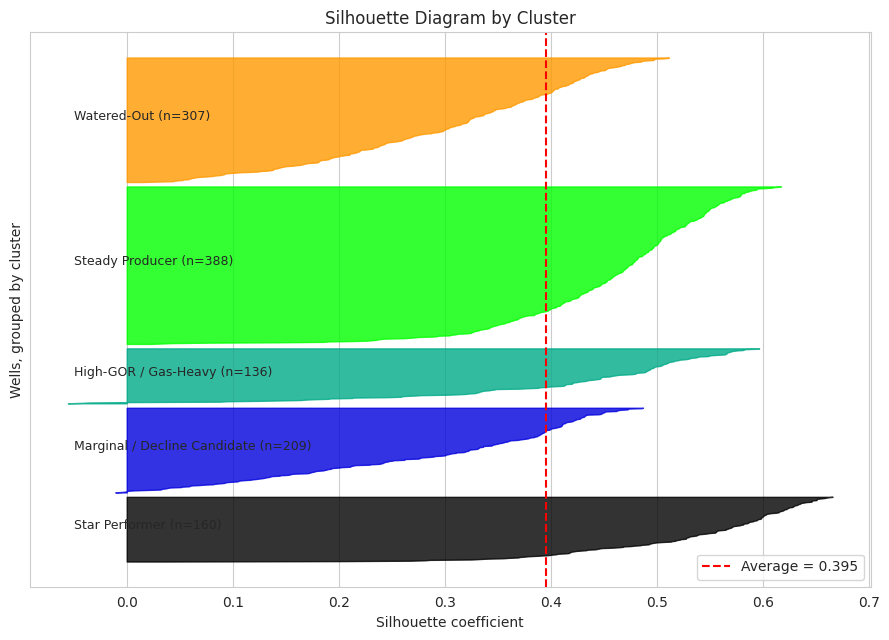

In [15]:

sample_silhouette_values = silhouette_samples(X_scaled, df['cluster'])

fig, ax = plt.subplots(figsize=(9, 6.5))
y_lower = 10
for i in sorted(df['cluster'].unique()):
    ith_values = sample_silhouette_values[df['cluster'] == i]
    ith_values.sort()
    size_i = ith_values.shape[0]
    y_upper = y_lower + size_i
    color = cm.nipy_spectral(float(i) / K_CHOSEN)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_values, facecolor=color, edgecolor=color, alpha=0.8)
    ax.text(-0.05, y_lower + 0.5 * size_i, f"{cluster_labels[i]} (n={size_i})", fontsize=9)
    y_lower = y_upper + 10

ax.axvline(x=overall_silhouette, color='red', linestyle='--', label=f"Average = {overall_silhouette:.3f}")
ax.set_xlabel("Silhouette coefficient")
ax.set_ylabel("Wells, grouped by cluster")
ax.set_title("Silhouette Diagram by Cluster")
ax.set_yticks([])
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()



### Explanation of the logic
Each colored wedge is one cluster; its width at any height is the silhouette value of one well, and wells are sorted within each wedge from worst to best. A **wide, uniformly positive wedge** (like Star Performer and High-GOR here) indicates a compact, well-separated cluster. A wedge with a **long, thin tail extending toward or past zero** (commonly seen for a "middle" cluster like Steady Producer) indicates wells that sit closer to the boundary with a neighboring cluster — i.e. wells whose classification is genuinely more ambiguous, which is realistic given that performance is a continuum.



## Step 9 — Sanity-Check: Comparing Discovered Segments to the Hidden Archetypes

In this teaching dataset only, we generated a hidden `_true_type` label. **In a real unsupervised project this label would not exist** — but here, we can use it as an answer key to confirm the clustering is finding something real, not noise.


In [16]:

cross_tab = pd.crosstab(df['segment'], df['_true_type'])
cross_tab


_true_type,High-GOR/Gas-Heavy,Marginal/Decline,Star Performer,Steady Producer,Watered-Out
segment,,,,,
High-GOR / Gas-Heavy,136,0,0,0,0
Marginal / Decline Candidate,0,200,0,0,9
Star Performer,0,0,159,1,0
Steady Producer,7,1,0,379,1
Watered-Out,0,52,0,0,255


Adjusted Rand Index (agreement between discovered clusters and hidden archetypes): 0.869
(1.0 = perfect agreement, 0.0 = agreement no better than random)


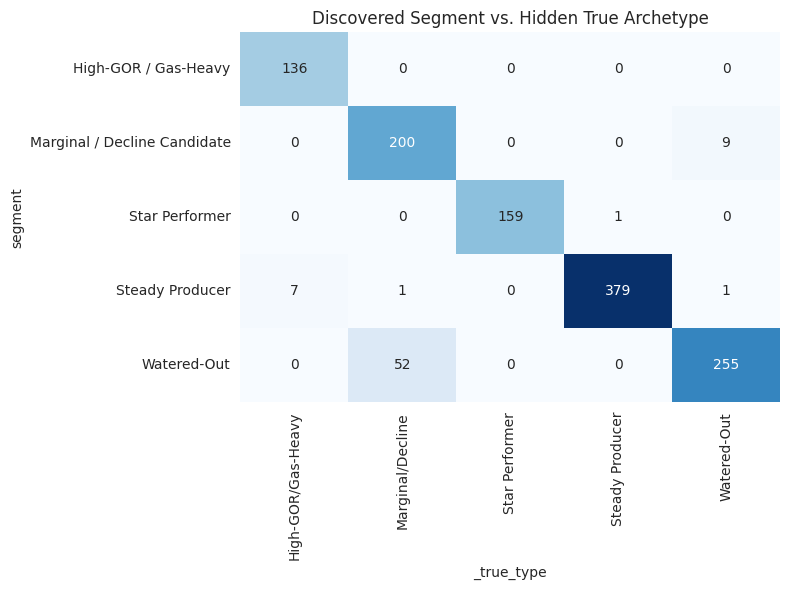

In [17]:

ari = adjusted_rand_score(df['_true_type'], df['cluster'])
print(f"Adjusted Rand Index (agreement between discovered clusters and hidden archetypes): {ari:.3f}")
print("(1.0 = perfect agreement, 0.0 = agreement no better than random)")

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
ax.set_title("Discovered Segment vs. Hidden True Archetype")
plt.tight_layout()
plt.show()



### Explanation of the logic
- The cross-tabulation shows that each discovered segment lines up strongly with one dominant hidden archetype (e.g. the wells labeled `Star Performer` by our clustering are overwhelmingly the wells we generated as true Star Performers) — visual confirmation that K-Means recovered real, meaningful structure using only the 6 unlabeled operational features.
- The **Adjusted Rand Index (ARI)** quantifies this agreement in a single number, corrected for chance. An ARI well above 0 (and typically above 0.5–0.6 for data with this much natural overlap) confirms the clustering captured genuine signal rather than arbitrary noise.
- **Teaching point:** you will essentially never have this validation step available in a real unsupervised project — that is precisely what makes unsupervised learning harder to validate than supervised learning. In practice, you validate clusters by checking (a) statistical measures like silhouette score, (b) whether the profiles make **domain sense**, and (c) — most importantly — whether **field engineers agree the segments are real and useful** once shown the profiles.



## Step 10 — From Segments to Action: A Recommendation per Cluster

Exactly as the classification lab converted risk scores into alert tiers, we now convert each discovered segment into a **recommended field action** — this is what makes the clustering analysis operationally useful rather than a purely academic exercise.


In [18]:

SEGMENT_ACTIONS = {
    'Star Performer': 'Protect and monitor. Prioritize for artificial-lift upgrades and workover budget to sustain performance; strong candidate for offset infill drilling nearby.',
    'Steady Producer': 'Business as usual. Standard surveillance cadence; periodic decline-curve review.',
    'Watered-Out': 'Evaluate water shut-off treatment or workover; if water cut and cost trend keep worsening, consider recompletion or plug-and-abandon economics.',
    'High-GOR / Gas-Heavy': 'Review choke management and check for gas coning; evaluate compression/gas-handling capacity; monitor for reservoir pressure depletion.',
    'Marginal / Decline Candidate': 'Run updated well economics; candidate for artificial-lift optimization, minor workover, or decommissioning if uneconomic.',
}

segment_summary = df.groupby('segment').agg(
    n_wells=('well_id', 'count'),
    avg_oil_rate_bopd=('avg_oil_rate_bopd', 'mean'),
    avg_water_cut_pct=('water_cut_pct', 'mean'),
    avg_decline_rate=('decline_rate_pct_per_month', 'mean'),
).round(1)
segment_summary['recommended_action'] = segment_summary.index.map(SEGMENT_ACTIONS)
segment_summary = segment_summary.sort_values('avg_oil_rate_bopd', ascending=False)
segment_summary


,n_wells,avg_oil_rate_bopd,avg_water_cut_pct,avg_decline_rate,recommended_action
segment,,,,,
Star Performer,160,851.4,8.4,2.4,Protect and monitor. Prioritize for artificial...
Steady Producer,388,395.5,25.3,5.0,Business as usual. Standard surveillance caden...
High-GOR / Gas-Heavy,136,289.8,15.1,6.2,Review choke management and check for gas coni...
Watered-Out,307,159.7,75.0,7.0,Evaluate water shut-off treatment or workover;...
Marginal / Decline Candidate,209,91.2,54.7,11.8,Run updated well economics; candidate for arti...


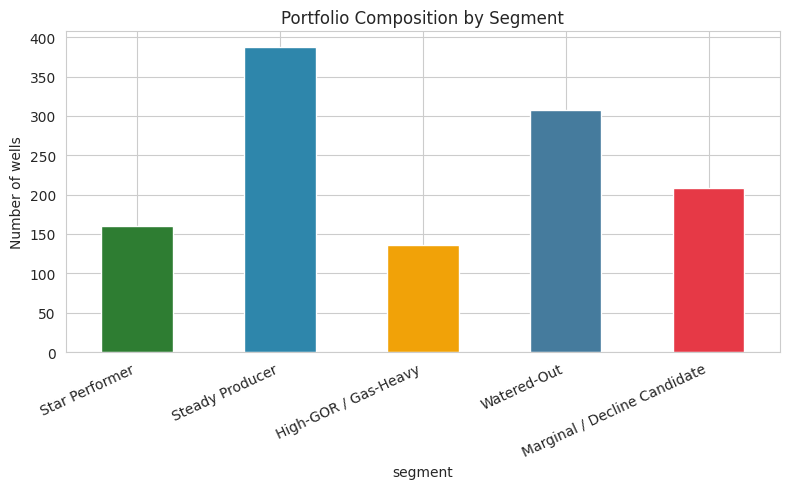

In [19]:

fig, ax = plt.subplots(figsize=(8, 5))
order = segment_summary.index
colors_map = [palette[s] for s in order]
segment_summary.loc[order, 'n_wells'].plot(kind='bar', color=colors_map, ax=ax)
ax.set_ylabel("Number of wells")
ax.set_title("Portfolio Composition by Segment")
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()



### Explanation of the logic
`SEGMENT_ACTIONS` is a transparent, human-readable lookup table — the unsupervised-learning equivalent of the `ACTION_MAP` used for alert tiers in the classification lab. Aggregating `segment_summary` by segment and attaching the recommended action turns a purely statistical grouping into a **portfolio management report**: a production engineering manager can now see exactly how many wells fall into each category, their average performance, and what to do about each group — without ever needing to understand the K-Means algorithm itself.



## Step 11 — End-to-End Function: Assigning New Wells to a Segment

We package scaling + cluster prediction + labeling + action lookup into a single reusable function — exactly the shape you would deploy as a monthly batch job that re-scores the well portfolio as new production data arrives.


In [20]:

def assign_well_segment(raw_df, scaler, kmeans_model, cluster_labels, feature_cols=feat_cols):
    '''
    Assign each well in raw_df to a K-Means segment and a recommended action.

    Parameters
    ----------
    raw_df : pd.DataFrame
        Must contain 'well_id' and all columns in feature_cols, in real (unscaled) units.
    scaler : fitted sklearn StandardScaler
        The SAME scaler fit on the original training data (Step 3) -- never refit on new data.
    kmeans_model : fitted sklearn KMeans
        The SAME trained model fit in Step 5.
    cluster_labels : dict
        Mapping from cluster number -> business segment name (Step 6).
    feature_cols : list
        The exact feature columns and order used during training.

    Returns
    -------
    pd.DataFrame with well_id, assigned cluster, segment name, and recommended action.
    '''
    X_new = raw_df[feature_cols]
    X_new_scaled = scaler.transform(X_new)          # transform ONLY, never fit, on new data
    cluster_pred = kmeans_model.predict(X_new_scaled)

    report = pd.DataFrame({
        'well_id': raw_df['well_id'].values,
        'cluster': cluster_pred,
    })
    report['segment'] = report['cluster'].map(cluster_labels)
    report['recommended_action'] = report['segment'].map(SEGMENT_ACTIONS)
    return report


In [21]:

# Simulate "new" incoming well data using a held-out sample of the same portfolio
new_wells = df.sample(10, random_state=1)[['well_id'] + feat_cols].reset_index(drop=True)

new_well_report = assign_well_segment(new_wells, scaler, kmeans, cluster_labels)
new_well_report


,well_id,cluster,segment,recommended_action
0,WELL-0636,4,Watered-Out,Evaluate water shut-off treatment or workover;...
1,WELL-0683,4,Watered-Out,Evaluate water shut-off treatment or workover;...
2,WELL-1033,3,Steady Producer,Business as usual. Standard surveillance caden...
3,WELL-0190,0,Star Performer,Protect and monitor. Prioritize for artificial...
4,WELL-1083,1,Marginal / Decline Candidate,Run updated well economics; candidate for arti...
5,WELL-0283,0,Star Performer,Protect and monitor. Prioritize for artificial...
6,WELL-0817,3,Steady Producer,Business as usual. Standard surveillance caden...
7,WELL-0314,1,Marginal / Decline Candidate,Run updated well economics; candidate for arti...
8,WELL-0537,3,Steady Producer,Business as usual. Standard surveillance caden...
9,WELL-0664,0,Star Performer,Protect and monitor. Prioritize for artificial...



### Explanation of the logic
- The function calls `scaler.transform()` — **never** `scaler.fit_transform()` — on new data. Refitting the scaler on new data would compute a different mean/standard deviation each time, silently breaking the consistency between how the model was trained and how it is applied. This mirrors the training/serving-skew warning from the classification lab, adapted to unsupervised learning.
- `kmeans_model.predict()` assigns each new, scaled well to its **nearest existing centroid** — the model does not re-cluster from scratch, it reuses the segment structure already learned from the training portfolio.
- The result is a small, self-contained report that could be generated monthly as new production data comes in, immediately telling engineers which segment (and recommended action) applies to every well in the field.



## Step 12 — Saving the Scaler and Model for Deployment


In [22]:

joblib.dump(scaler, "well_segmentation_scaler.joblib")
joblib.dump(kmeans, "well_segmentation_kmeans.joblib")
joblib.dump(cluster_labels, "well_segmentation_cluster_labels.joblib")

df.drop(columns=['_true_type']).to_csv("well_segments_scored.csv", index=False)

print("Saved artifacts:")
print(" - well_segmentation_scaler.joblib       (fitted StandardScaler)")
print(" - well_segmentation_kmeans.joblib       (fitted KMeans model, K=5)")
print(" - well_segmentation_cluster_labels.joblib (cluster number -> business label mapping)")
print(" - well_segments_scored.csv              (full portfolio with assigned segments)")


Saved artifacts:
 - well_segmentation_scaler.joblib       (fitted StandardScaler)
 - well_segmentation_kmeans.joblib       (fitted KMeans model, K=5)
 - well_segmentation_cluster_labels.joblib (cluster number -> business label mapping)
 - well_segments_scored.csv              (full portfolio with assigned segments)



### Explanation of the logic
**All three artifacts must be saved and reloaded together**: the scaler, the K-Means model, and the label mapping. Saving the model alone is not enough — without the exact same fitted scaler, new data would be transformed inconsistently with how the model was trained, and without the label mapping, cluster numbers 0–4 are meaningless to a business user.



## Step 13 — Lab Summary & Key Takeaways

| Concept | What We Did |
|---|---|
| **Unsupervised vs. supervised** | No target column was used at any point in training — K-Means discovered structure from feature similarity alone |
| **Mandatory scaling** | Applied `StandardScaler` before clustering, since K-Means is distance-based and sensitive to feature units — unlike the tree-based models in the classification lab |
| **Choosing K** | Combined the Elbow Method and Silhouette Analysis with domain interpretability to justify K = 5 over the marginally higher-scoring K = 4 |
| **Cluster profiling** | Translated numeric centroids into plain-English business segments (Star Performer, Watered-Out, etc.) |
| **Visualization** | Used PCA to compress 6 dimensions into a 2D scatter plot for intuitive presentation |
| **Validation** | Used a hidden ground-truth label (available only in this teaching exercise) and the Adjusted Rand Index to confirm the clusters reflect real structure |
| **Business actions** | Attached a concrete recommended field action to every segment |
| **Deployment** | Wrapped scaling + prediction + labeling into one function that scores new wells against the existing segmentation |

### Exercises for Further Practice
1. Re-run Step 4 using **K = 4** instead of 5. Profile the resulting clusters — which two of the five original segments merge together, and does the merged group still make business sense?
2. Add `well_depth_ft`, `porosity_pct`, and `permeability_md` into the clustering feature set (instead of using them only for profiling). Does the silhouette score improve or worsen, and why might static reservoir properties dilute a *performance*-based segmentation?
3. Try **Hierarchical (Agglomerative) Clustering** or **DBSCAN** on the same scaled features and compare the resulting segments to the K-Means result.
4. Investigate the wells with the **lowest individual silhouette values** (Step 8) — are they genuinely ambiguous, or might they indicate outliers/data-quality issues worth a separate review?
5. Extend `SEGMENT_ACTIONS` into a full workover-budget prioritization: rank wells within the `Marginal/Decline` segment by expected economic uplift from intervention.

---
### Instructor Notes (Facilitation Guide)
- **Pacing:** Steps 0–2 setup/EDA (~20 min), Steps 3–5 scaling & choosing K & fitting (~30 min), Steps 6–9 profiling/visualization/validation (~35 min), Steps 10–12 business actions & deployment (~20 min), wrap-up (~10 min). Total ≈ 115 minutes.
- **Common learner mistakes to watch for:** (1) forgetting to scale features before clustering — demonstrate the distorted result of skipping Step 3 if time allows; (2) treating the silhouette-optimal K as an automatic, non-negotiable choice rather than one input to a business decision; (3) calling `scaler.fit_transform()` instead of `scaler.transform()` on new data in Step 11 — this is the single most common production bug in deployed clustering pipelines.
- **Discussion prompt:** ask the class, *"If two candidate values of K score almost identically on silhouette, what other factors should break the tie?"* — steer the conversation toward interpretability, stakeholder buy-in, and whether the resulting segments map to actions the business can actually take.
